# FPDE Plotting Example

This notebook checks the optional FPDE plotting helpers across local, batch, image, prototype, and validation views:

- `plot_attributions` for a local contribution bar plot
- `plot_attribution_waterfall` for a cumulative local plot
- `plot_local_contributions` for signed local contribution labels
- `plot_attribution_summary` for a batch contribution summary plot
- `fpde.plots` for compact contribution plotting helpers
- `plot_attribution_image` for vector-as-image heatmaps
- `plot_similarity_distribution` for representative similarity histograms
- `plot_prototype_similarity_distribution` for FPDE-native prototype similarity distributions
- `plot_perturbation_curves` for deletion and insertion validation curves

Install the plotting extra before running this notebook:

```bash
python -m pip install -e ".[plot]"
```

In [1]:
from pathlib import Path
import sys
import importlib.util

for candidate in (Path.cwd() / "src", Path.cwd().parent / "src"):
    if (candidate / "fpde").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break

missing = [pkg for pkg in ("matplotlib", "sklearn") if importlib.util.find_spec(pkg) is None]
if missing:
    raise RuntimeError(
        "Missing notebook dependencies: "
        + ", ".join(missing)
        + ". Install them with: python -m pip install -e \".[plot]\""
    )

print("Plotting dependencies are available.")

Plotting dependencies are available.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from fpde import (
    FPDEEngine,
    compute_prototype_similarities,
    perturbation_curves,
    plot_attribution_image,
    plot_attribution_summary,
    plot_attribution_waterfall,
    plot_attributions,
    plot_local_contributions,
    plot_perturbation_curves,
    plot_prototype_similarity_distribution,
    plot_similarity_distribution,
)
from fpde.plots import (
    FPDEPlotExplanation,
    bar,
    beeswarm,
    scatter,
    waterfall as contribution_waterfall,
)

In [3]:
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data,
    data.target,
    test_size=0.25,
    random_state=7,
    stratify=data.target,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=2000, random_state=7)
model.fit(X_train_scaled, y_train)

engine = FPDEEngine.fit(X_train_scaled, y_train, model=model)
x = X_test_scaled[0]
attributions, details = engine.explain_one(x, lambda_hyb=0.5)

print(f"Predicted class: {details['target_label']}")
print(f"Rival class: {details['rival_label']}")
print(f"Target probability: {details['target_probability']:.3f}")
print(f"Evidence: {details['evidence']:.4f}")

Predicted class: 1
Rival class: 0
Target probability: 0.999
Evidence: 0.6511


## Attribution Bar Plot

Positive bars support the predicted target class relative to the rival class. Negative bars support the rival class.

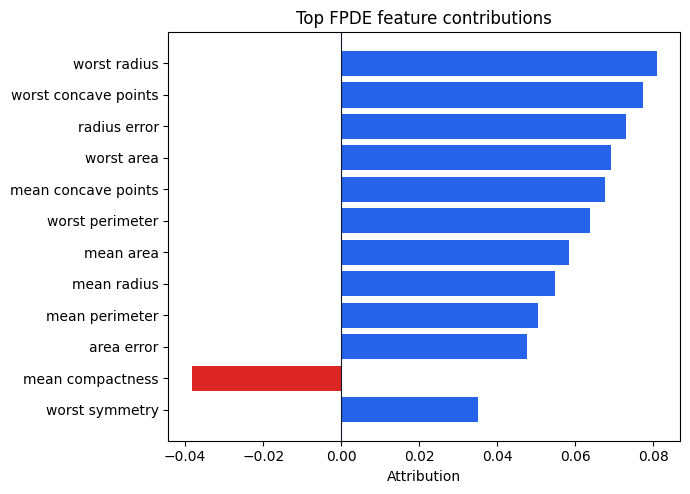

In [4]:
ax = plot_attributions(
    attributions,
    feature_names=data.feature_names,
    top_k=12,
    title="Top FPDE feature contributions",
)
plt.tight_layout()
plt.show()

## Similarity Distribution

`plot_similarity_distribution` shows a single similarity histogram and can mark the explained sample.

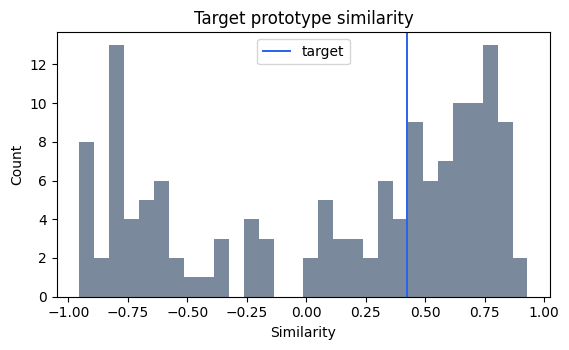

In [5]:
target_idx = int(np.where(engine.prototype_labels == details["target_label"])[0][0])
target_similarities = compute_prototype_similarities(
    X_test_scaled,
    engine.prototypes[target_idx],
    metric="cosine",
)
sample_target_similarity = compute_prototype_similarities(
    [x],
    engine.prototypes[target_idx],
    metric="cosine",
)[0]

ax = plot_similarity_distribution(
    target_similarities,
    target_similarity=sample_target_similarity,
    title="Target prototype similarity",
)
plt.tight_layout()
plt.show()

## Signed Local Contribution Plot

`plot_local_contributions` formats one FPDE attribution vector as a signed feature contribution chart with optional feature values in the labels.

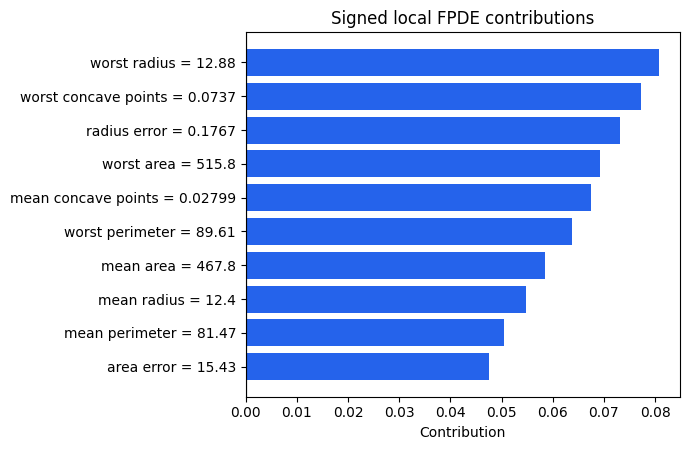

In [6]:
ax = plot_local_contributions(
    data.feature_names,
    attributions,
    values=X_test[0],
    top_k=10,
    title="Signed local FPDE contributions",
)
plt.tight_layout()
plt.show()

## Attribution Waterfall

This shows how the largest signed FPDE contributions accumulate to the final target-versus-rival evidence.

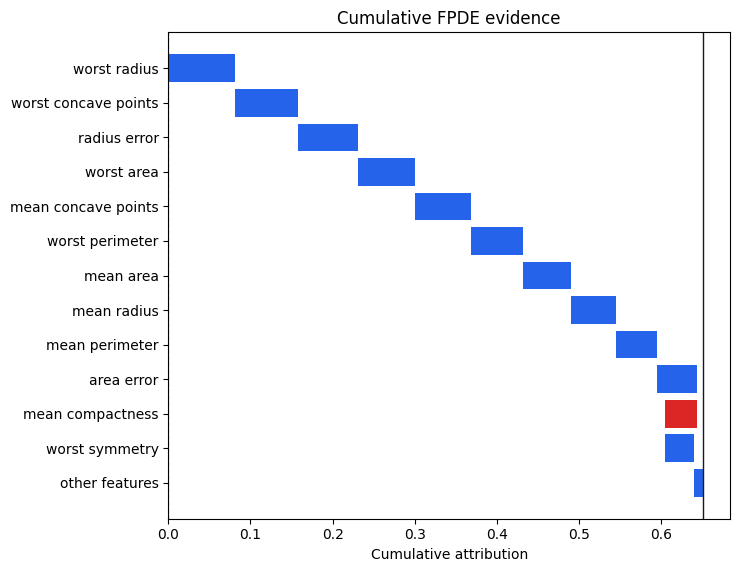

In [7]:
ax = plot_attribution_waterfall(
    attributions,
    feature_names=data.feature_names,
    top_k=12,
    title="Cumulative FPDE evidence",
)
plt.tight_layout()
plt.show()

## Batch Attribution Summary

This batch view orders features by mean absolute FPDE attribution and colors points by standardized feature value.

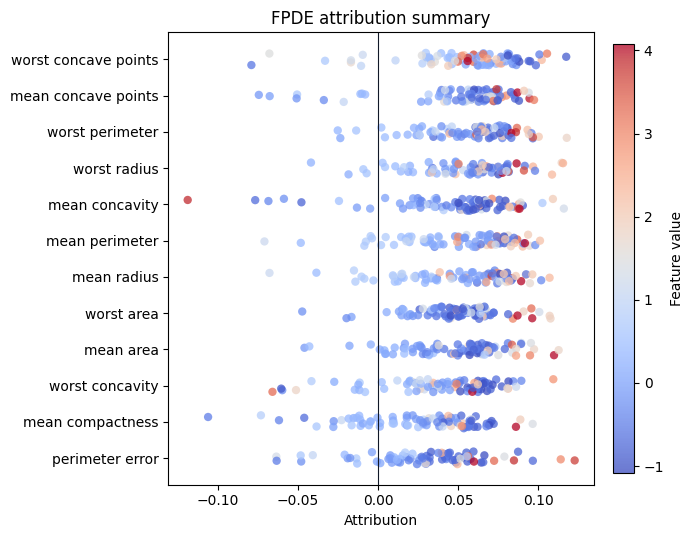

In [8]:
batch_X = X_test_scaled[:80]
batch_attributions = engine.explain_matrix(batch_X, lambda_hyb=0.5)

ax = plot_attribution_summary(
    batch_attributions,
    feature_values=batch_X,
    feature_names=data.feature_names,
    top_k=12,
    title="FPDE attribution summary",
)
plt.tight_layout()
plt.show()

## Compact Contribution Plot API

`fpde.plots` accepts arrays or `FPDEPlotExplanation` containers and returns matplotlib Axes. Use `show=False` when saving figures or composing subplots.

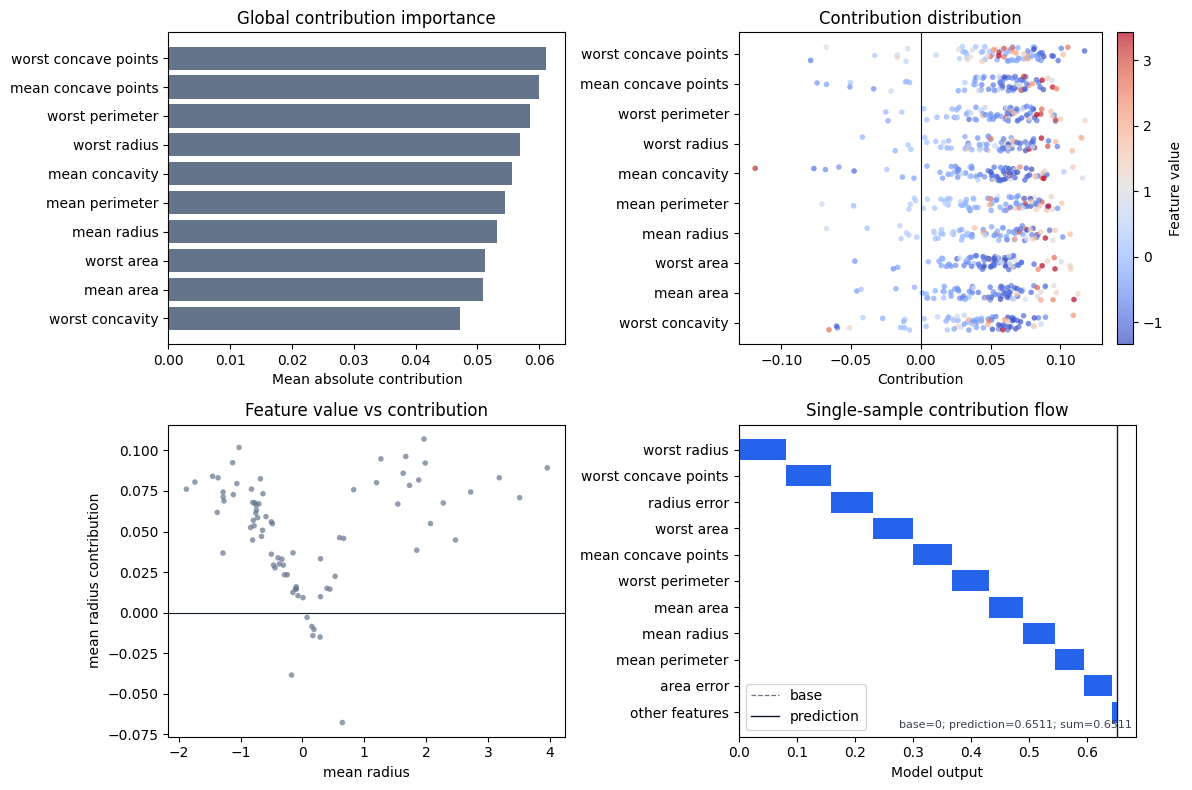

In [9]:
plot_exp = FPDEPlotExplanation(
    values=batch_attributions,
    data=batch_X,
    feature_names=data.feature_names,
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
bar(plot_exp, max_display=10, ax=axes[0, 0], show=False, title="Global contribution importance")
beeswarm(plot_exp, max_display=10, ax=axes[0, 1], show=False, title="Contribution distribution")
scatter(plot_exp, feature=data.feature_names[0], ax=axes[1, 0], show=False, title="Feature value vs contribution")
contribution_waterfall(
    values=attributions,
    base_value=0.0,
    prediction=float(np.sum(attributions)),
    feature_names=data.feature_names,
    max_display=10,
    ax=axes[1, 1],
    show=False,
    title="Single-sample contribution flow",
)
fig.tight_layout()
plt.show()

## Attribution Heatmap

The breast cancer dataset has 30 tabular features, so this reshapes the vector to a compact 5x6 diagnostic grid for visual smoke testing.

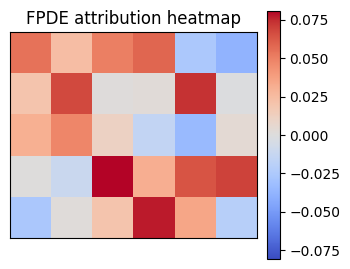

In [10]:
ax = plot_attribution_image(
    attributions,
    shape=(5, 6),
    title="FPDE attribution heatmap",
)
plt.tight_layout()
plt.show()

## Prototype Similarity Distribution

This FPDE-native view compares held-out samples with the selected target and rival prototypes, then marks the explained sample.

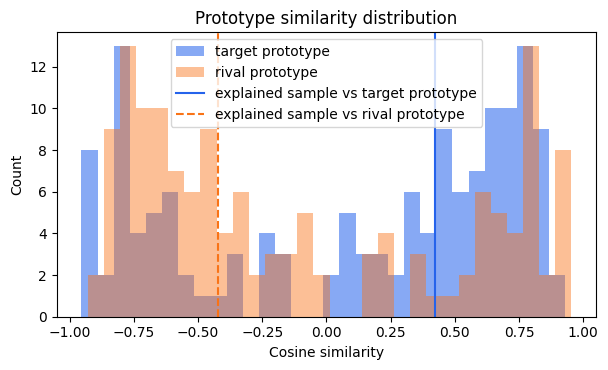

In [11]:
target_idx = int(np.where(engine.prototype_labels == details["target_label"])[0][0])
rival_idx = int(np.where(engine.prototype_labels == details["rival_label"])[0][0])

ax = plot_prototype_similarity_distribution(
    X_test_scaled,
    engine.prototypes[target_idx],
    rival_prototype=engine.prototypes[rival_idx],
    x=x,
    metric="cosine",
    title="Prototype similarity distribution",
)
plt.tight_layout()
plt.show()

## Perturbation Curves

Deletion replaces the most positive-attribution features with the baseline. Insertion starts from the baseline and restores them.

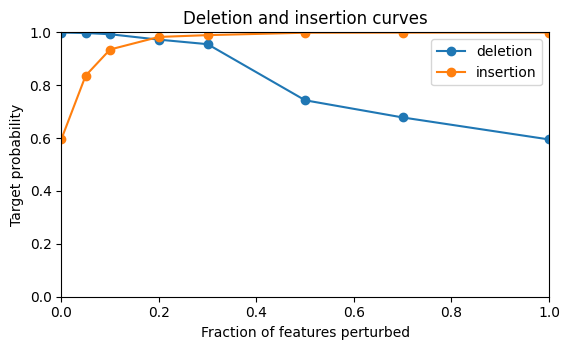

Deletion drop AUC: 0.2021
Insertion AUC: 0.9728
Combined score: 0.5875


In [12]:
curves = perturbation_curves(
    model,
    x,
    attributions,
    details["target_label"],
    engine.baseline,
)

ax = plot_perturbation_curves(curves, title="Deletion and insertion curves")
plt.tight_layout()
plt.show()

print(f"Deletion drop AUC: {curves['deletion_drop_auc']:.4f}")
print(f"Insertion AUC: {curves['insertion_auc']:.4f}")
print(f"Combined score: {curves['combined_score']:.4f}")